In [29]:
pip install pandas numpy matplotlib seaborn jupyter ta

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd

df = pd.read_csv("../data/raw/Data/AAPL.csv")

In [31]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB


In [33]:
print(df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [34]:
df = df.dropna()

In [35]:
df["Date"] = pd.to_datetime(df["Date"])

In [36]:
df.set_index("Date", inplace=True)

In [37]:
from ta.trend import SMAIndicator

In [38]:
sma_20 = SMAIndicator(close=df["Close"], window=20)

df["SMA_20"] = sma_20.sma_indicator()

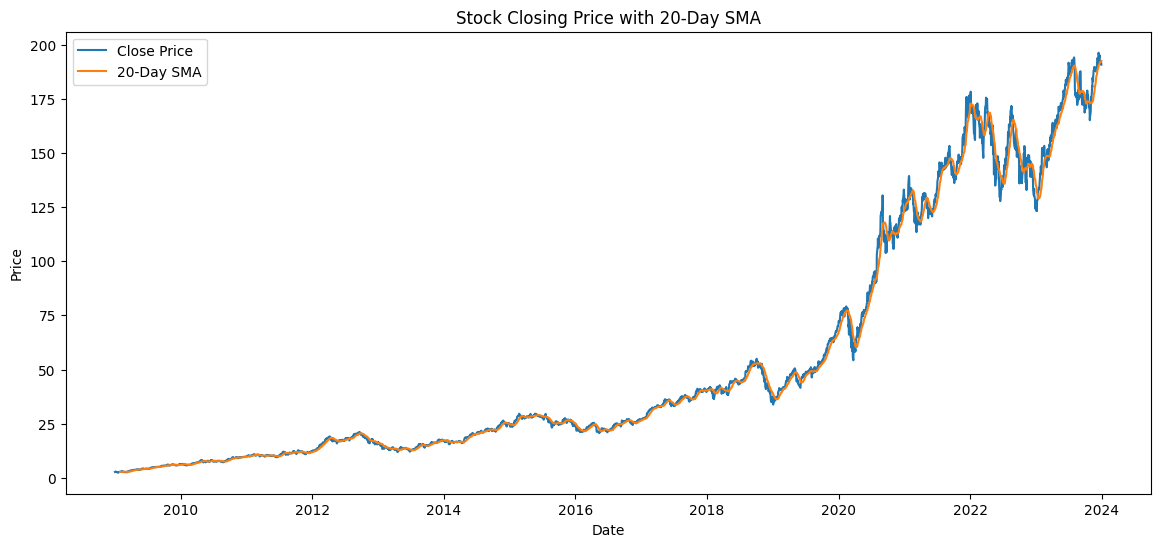

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], label="Close Price")

plt.plot(df.index, df["SMA_20"], label="20-Day SMA")

plt.title("Stock Closing Price with 20-Day SMA")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [40]:
from ta.trend import EMAIndicator

In [41]:
ema_20 = EMAIndicator(close=df["Close"], window=20)

df["EMA_20"] = ema_20.ema_indicator()

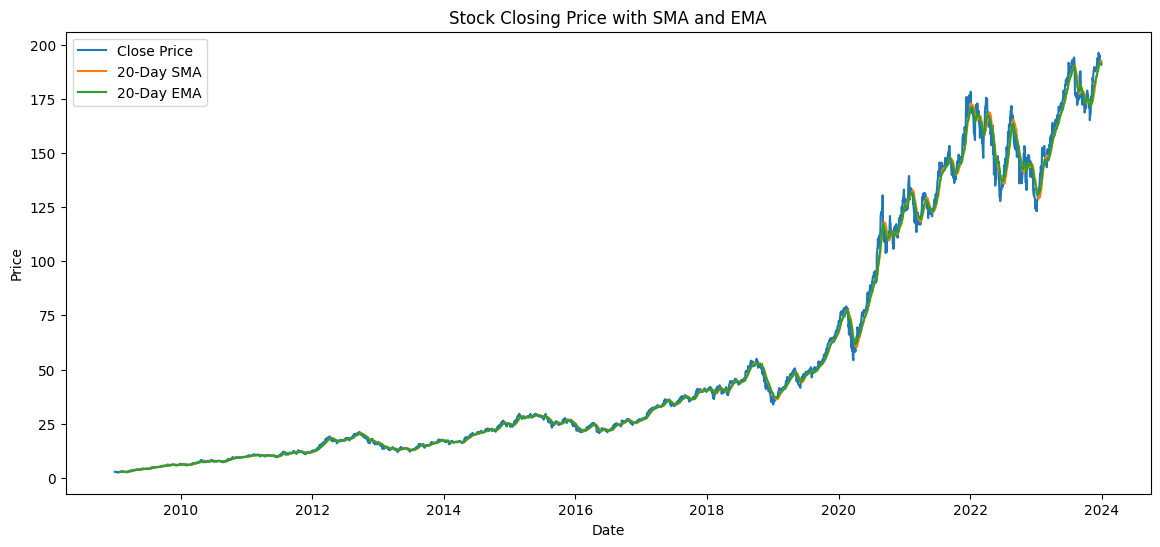

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close"], label="Close Price")

plt.plot(df.index, df["SMA_20"], label="20-Day SMA")

plt.plot(df.index, df["EMA_20"], label="20-Day EMA")

plt.title("Stock Closing Price with SMA and EMA")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

The SMA and EMA indicators helped smooth short-term stock price fluctuations and made broader market trends easier to observe.

The EMA followed the stock price more closely than the SMA because it gives greater importance to recent prices. This allowed the EMA to react faster to sudden market changes.

Periods where the stock price remained above both moving averages may indicate positive market momentum, while periods below the indicators may suggest downward pressure or market correction.